In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('diabetic_data.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.replace('?', np.nan, inplace=True)

df.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)

df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace=True)

df['readmission_target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Target distribution (0 = Not Readmitted <30 days, 1 = Readmitted <30 days):")
print(df['readmission_target'].value_counts(normalize=True))
     


Target distribution (0 = Not Readmitted <30 days, 1 = Readmitted <30 days):
readmission_target
0    0.887143
1    0.112857
Name: proportion, dtype: float64


In [6]:
age_dict = {'[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45, 
            '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95}
df['age'] = df['age'].map(age_dict)

le = LabelEncoder()
categorical_cols = ['race', 'gender', 'change', 'diabetesMed']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
            'num_medications', 'number_outpatient', 'number_emergency', 
            'number_inpatient', 'number_diagnoses', 'race', 'gender', 'diabetesMed']

X = df[features]
y = df['readmission_target']

In [7]:
print(X.head())

   age  time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
1  NaN                 3                  59               0               18   
2  NaN                 2                  11               5               13   
3  NaN                 2                  44               1               16   
4  NaN                 1                  51               0                8   
5  NaN                 3                  31               6               16   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  \
1                  0                 0                 0                 9   
2                  2                 0                 1                 6   
3                  0                 0                 0                 7   
4                  0                 0                 0                 5   
5                  0                 0                 0                 9   

   race  gender  diabetesMed  
1     2      

Accuracy Score: 0.8811891285503034

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     17408
           1       0.19      0.02      0.03      2203

    accuracy                           0.88     19611
   macro avg       0.54      0.50      0.48     19611
weighted avg       0.81      0.88      0.84     19611



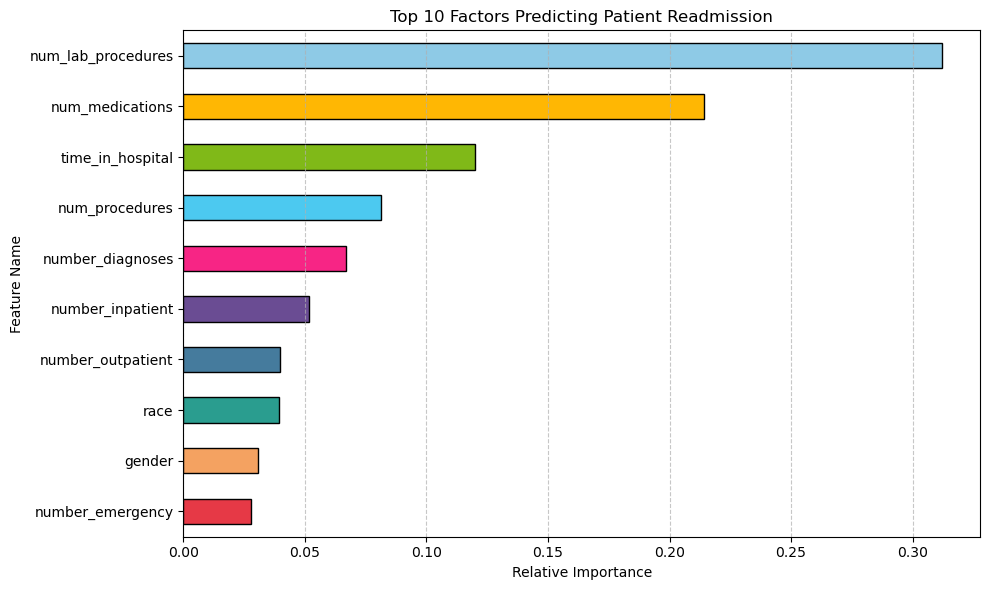

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feat_importances.nlargest(10).sort_values()

colors = [
    '#e63946', '#f4a261', '#2a9d8f', '#457b9d', '#6a4c93',
    '#f72585', '#4cc9f0', '#80b918', '#ffb703', '#8ecae6'
]

top_features.plot(kind='barh', color=colors, edgecolor='black')

plt.title('Top 10 Factors Predicting Patient Readmission')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()